In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
max_words = 5000  # Maximum number of words in the vocabulary
max_len = 10      # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = data[target_column]

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Word2Vec model or load pre-trained model
# Tokenize text for Word2Vec
tokenized_text = [text.split() for text in data[text_column]]  # Split text into words

# Train a Word2Vec model (adjust parameters as necessary)
word2vec_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# Step 4: Prepare Word2Vec embedding matrix
embedding_dim = 100
embedding_matrix = np.zeros((max_words, embedding_dim))

# Populate the embedding matrix with Word2Vec vectors
for word, index in tokenizer.word_index.items():
    if index < max_words:
        try:
            embedding_vector = word2vec_model.wv[word]
            embedding_matrix[index] = embedding_vector
        except KeyError:
            continue  # If the word isn't in Word2Vec model

# Step 5: Build the BiLSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.2),  # Optional dropout to prevent overfitting
    Bidirectional(LSTM(64, return_sequences=False)),  # Bidirectional LSTM layer
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the BiLSTM model
print("Training BiLSTM Model...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the BiLSTM model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"BiLSTM Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Save the trained BiLSTM model
model_path = r"C:\Users\PC\Downloads\BiLSTM_word2vec_model.h5"  # File path to save the model
model.save(model_path)
print(f"Trained BiLSTM model saved to {model_path}")

# Step 9: Make predictions and calculate additional metrics
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Step 10: Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training BiLSTM Model...
Epoch 1/10


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4641/4641 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.8774 - loss: 0.2907 - val_accuracy: 0.9117 - val_loss: 0.2127
Epoch 2/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.9137 - loss: 0.2141 - val_accuracy: 0.9165 - val_loss: 0.2052
Epoch 3/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.9202 - loss: 0.1977 - val_accuracy: 0.9190 - val_loss: 0.2004
Epoch 4/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9252 - loss: 0.1874 - val_accuracy: 0.9161 - val_loss: 0.2083
Epoch 5/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9280 - loss: 0.1802 - val_accuracy: 0.9178 - val_loss: 0.2028
Epoch 6/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9310 - loss: 0.1736 - val_accuracy: 0.9181 - val_loss: 0.2056
Epoch 7/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.9334 - loss: 0.1669 - val_accuracy: 0.9179 - val_loss: 0.2071
Epoch 8/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.9346 - loss: 0.1633 - val


Trained BiLSTM model saved to C:\Users\PC\Downloads\BiLSTM_word2vec_model.h5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Accuracy: 92.02%
Precision: 92.34%
Recall: 91.61%
F1 Score: 91.97%
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     23238
           1       0.92      0.92      0.92     23171

    accuracy                           0.92     46409
   macro avg       0.92      0.92      0.92     46409
weighted avg       0.92      0.92      0.92     46409



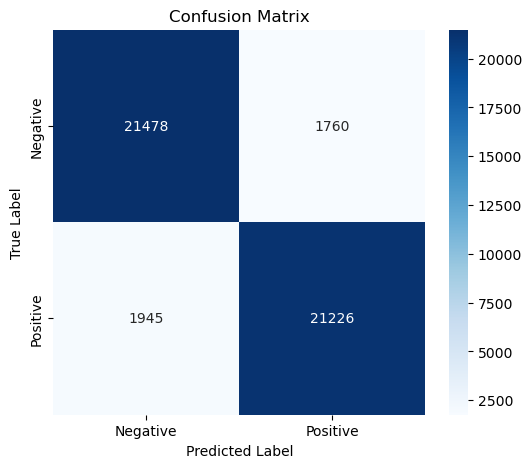

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 11: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix using seaborn heatmap for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


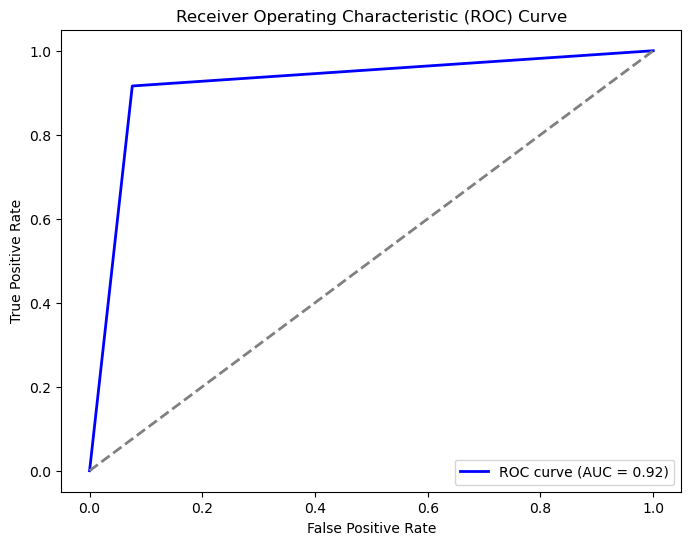

In [3]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 12: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Random classifier line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Training BiLSTM model with Word2Vec embeddings...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.8762 - loss: 0.2914 - val_accuracy: 0.9131 - val_loss: 0.2140
Epoch 2/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9138 - loss: 0.2130 - val_accuracy: 0.9167 - val_loss: 0.2051
Epoch 3/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9201 - loss: 0.1977 - val_accuracy: 0.9169 - val_loss: 0.2046
Epoch 4/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9244 - loss: 0.1879 - val_accuracy: 0.9181 - val_loss: 0.2033
Epoch 5/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9277 - loss: 0.1795 - val_accuracy: 0.9187 - val_loss: 0.2030
Epoch 6/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9310 - loss: 0.1730 - val_accuracy: 0.9197 - val_loss: 0.2070
Epoch 7/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.9329 - loss: 0.1676 - val_accuracy: 0.9187 - val_loss: 0.2062
Epoch 8/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9348 - loss: 

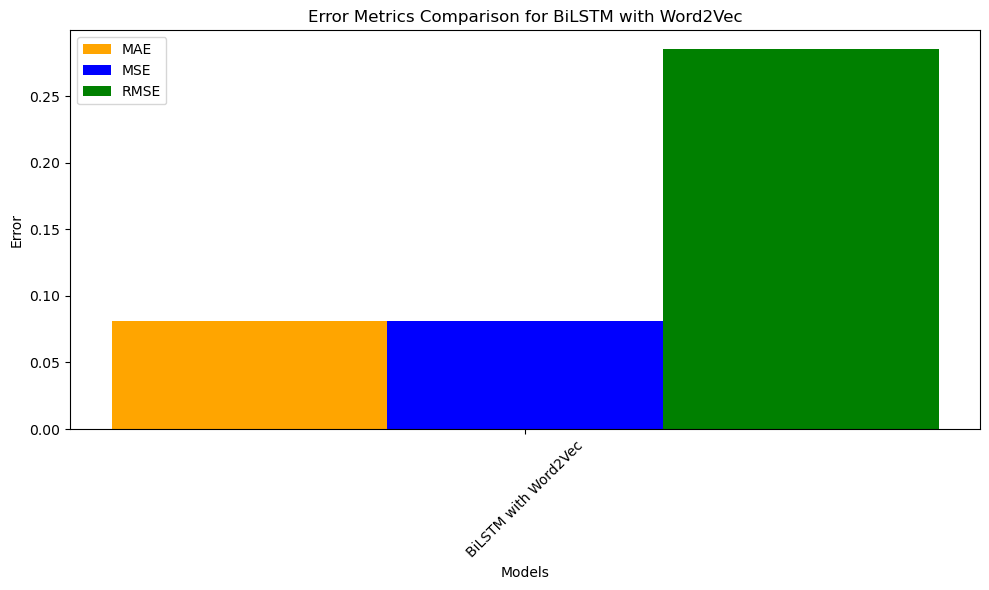

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Dictionary to store error metrics
error_metrics = {}

# Assuming you have pre-trained Word2Vec model
# Example: word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Example of loading a pre-trained Word2Vec model
# word2vec_model = Word2Vec.load("path_to_your_pretrained_word2vec_model")

# Tokenize the text and create a tokenizer
max_words = 5000
max_len = 10

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])  # Assuming `data[text_column]` is your text column
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Create Word2Vec embedding matrix
embedding_dim = 100  # Example dimension of Word2Vec embeddings
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    try:
        # Assuming you have a Word2Vec model trained or loaded
        embedding_vector = word2vec_model.wv[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        embedding_matrix[i] = np.zeros(embedding_dim)

# Initialize and train the BiLSTM model with Word2Vec embeddings
print("Training BiLSTM model with Word2Vec embeddings...")
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim, input_length=max_len, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.2),  # Optional dropout to prevent overfitting
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Predict on the test set
y_pred_bilstm = (model.predict(X_test) > 0.5).astype("int32")

# Calculate error metrics
mae_bilstm = mean_absolute_error(y_test, y_pred_bilstm)
mse_bilstm = mean_squared_error(y_test, y_pred_bilstm)
rmse_bilstm = np.sqrt(mse_bilstm)

# Store error metrics
error_metrics["BiLSTM with Word2Vec"] = {"MAE": mae_bilstm, "MSE": mse_bilstm, "RMSE": rmse_bilstm}

# Print metrics
print(f"BiLSTM with Word2Vec MAE: {mae_bilstm:.4f}, MSE: {mse_bilstm:.4f}, RMSE: {rmse_bilstm:.4f}")

# Visualization (same format as requested)
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

# Create the bar plot for error metrics comparison
plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for BiLSTM with Word2Vec')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


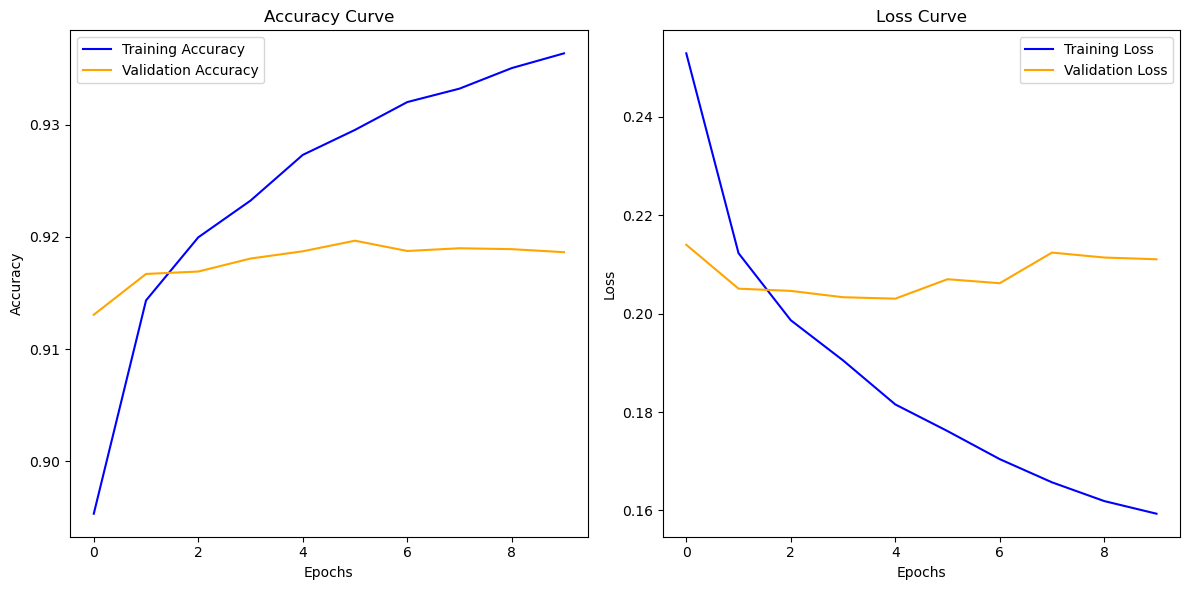

In [7]:
import matplotlib.pyplot as plt

# Plot the accuracy curve
plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')

# Plot the loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.tight_layout()
plt.show()
